In [13]:
#Step#1: Import the libraries
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# Step#2: Define Functions

def sample_image(image, factor):
    # Downsamples the image by the given factor
    
    # Args:
    # image (numpy array): Original image
    # factor (int): Factor by which to downsample
    
    # Returns:
    # numpy array: Downsampled image
    
    height, width = image.shape[:2]
    sampled_image = cv2.resize(
        image,
        (width // factor, height // factor),
        interpolation=cv2.INTER_NEAREST
    )
    return sampled_image


def quantize_image(image, levels):
    # Reduces the number of grayscale levels in the image
    
    # Args:
    # image (numpy array): Original image
    # levels (int): Number of grayscale levels
    
    # Returns:
    # numpy array: Quantized image
    
    quantized_image = np.floor(
        image / (256 // levels)
    ) * (256 // levels)
    
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


def plot_images(original, sampled, quantized):
    # Plots the original, sampled, and quantized images side by side
    
    # Args:
    # original (numpy array): Original image
    # sampled (numpy array): Sampled image
    # quantized (numpy array): Quantized image
    
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')

    plt.show()

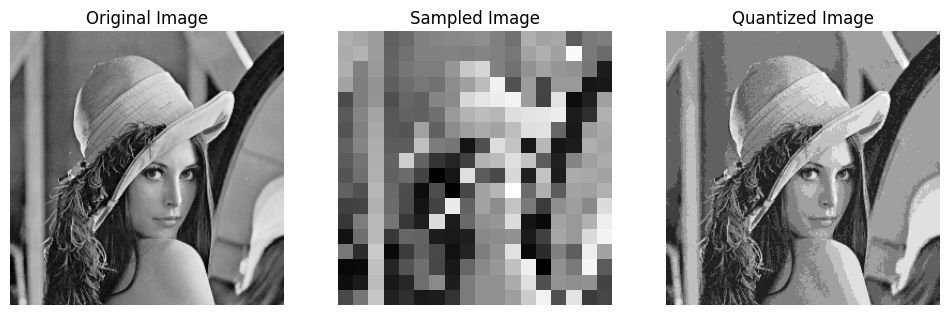

In [9]:
# Step#3: Import the image and set the parameters

image_path = 'lena_gray_256.tif'

sampling_factor = 14
quantization_levels = 9

# Load image in grayscale
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if original_image is None:
    print(f"Error: Unable to load image at {image_path}")
else:
    # Sample and quantize
    sampled_image = sample_image(original_image, sampling_factor)
    quantized_image = quantize_image(original_image, quantization_levels)

    # Plot results
    plot_images(original_image, sampled_image, quantized_image)

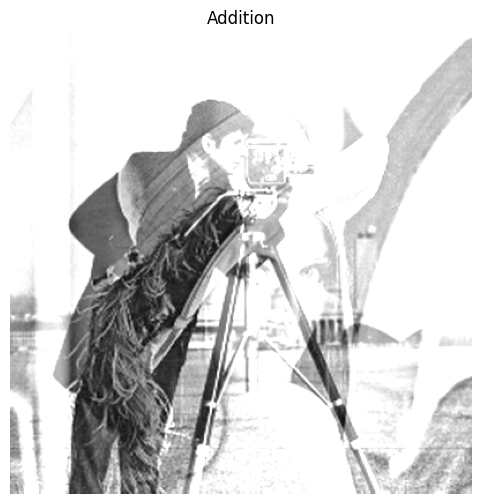

In [37]:
# Arithmetic Operations

img1 = Image.open('lena_gray_256.tif')
img2 = Image.open('cameraman.tif')

resize = (400, 400)

img1 = img1.resize(resize, Image.Resampling.LANCZOS)
img2 = img2.resize(resize, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

addition = cv2.add(im1arr, im2arr)

plt.figure(figsize=(6,6))
plt.imshow(addition, cmap='gray')
plt.axis('off')
plt.title("Addition")
plt.show()

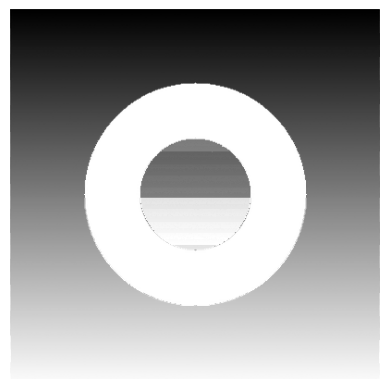

In [20]:
# Sets and Logical Operations

img3 = Image.open('A.png')
img4 = Image.open('B.png')

resize = (400, 400)

img3 = img3.resize(resize, Image.Resampling.LANCZOS)
img4 = img4.resize(resize, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr

plt.imshow(union, cmap='gray')
plt.axis('off')
plt.show()

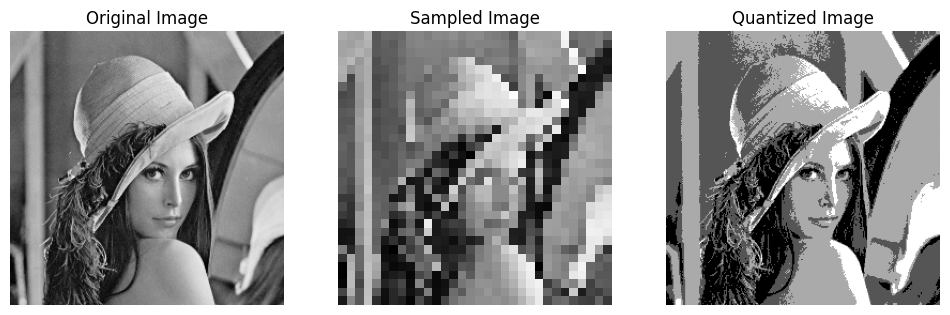

In [21]:
# Task#1

# Change the sampling and quantization parameters
image_path = 'lena_gray_256.tif'

sampling_factor = 8
quantization_levels = 4

# Load image
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if original_image is None:
    print(f"Error: Unable to load image at {image_path}")
else:
    sampled_image = sample_image(original_image, sampling_factor)
    quantized_image = quantize_image(original_image, quantization_levels)

    plot_images(original_image, sampled_image, quantized_image)

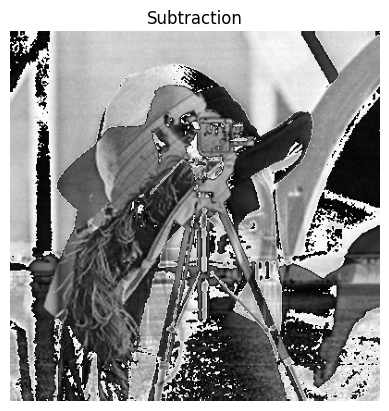

In [22]:
# Task#2.1
# Subtract two images and display the result

subtract = im1arr - im2arr

plt.imshow(subtract, cmap='gray')
plt.axis('off')
plt.title("Subtraction")
plt.show()

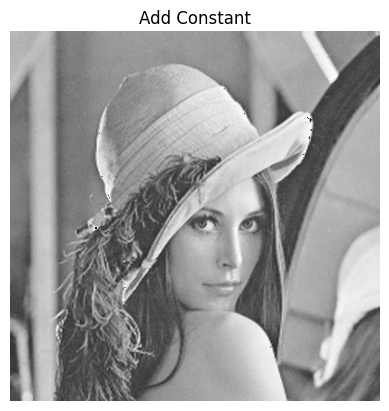

In [34]:
# Task#2.2
# Add one image with a constant value 175 and display it

add_constant = im1arr + 23

plt.imshow(add_constant, cmap='gray')
plt.axis('off')
plt.title("Add Constant")
plt.show()

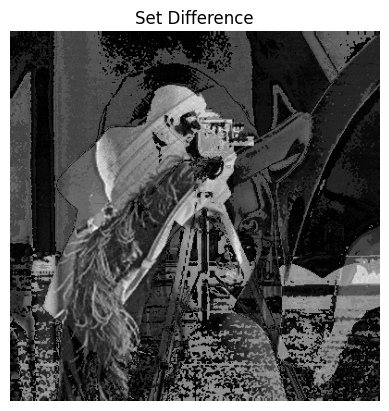

In [24]:
# Task#2.3
# Apply the set difference operation on two Gray-Scale images

difference = im1arr & (~im2arr)

plt.imshow(difference, cmap='gray')
plt.axis('off')
plt.title("Set Difference")
plt.show()

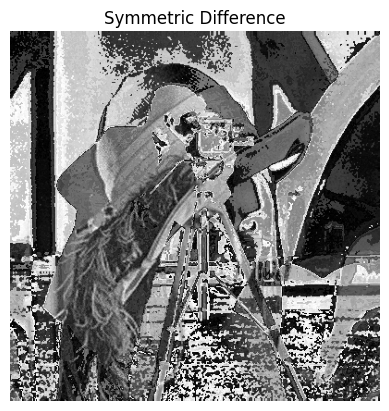

In [25]:
# Task#2.4
# Apply the symmetric difference operation on two Gray-Scale images

symmetric_difference = im1arr ^ im2arr

plt.imshow(symmetric_difference, cmap='gray')
plt.axis('off')
plt.title("Symmetric Difference")
plt.show()

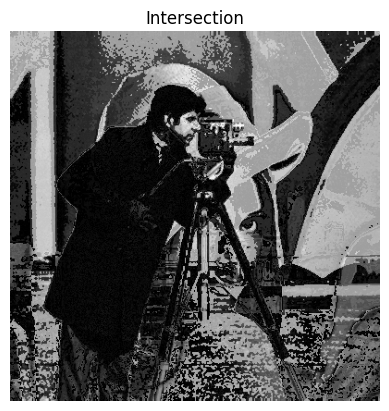

In [26]:
# Task#2.5
# Apply Intersection operation on two Gray-Scale images

intersection = im1arr & im2arr

plt.imshow(intersection, cmap='gray')
plt.axis('off')
plt.title("Intersection")
plt.show()